In [1]:
from datasetgenerator import *
from params import *
import pandas as pd
import einops
import numpy as np
from sklearn.model_selection import train_test_split
import nibabel
import torch
import monai
import fastai
print("PyTorch version:", torch.__version__)
print("MONAI version:", monai.__version__)
print("Fastai version:", fastai.__version__)
from functools import partial
from fastai.vision.all import *
from monai.networks.nets import UNet, DynUNet
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, Resize, ToTensor
from monai.transforms import SpatialPad, CenterSpatialCrop, Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, ToTensor
from monai.losses import DiceLoss
from fastai.metrics import Dice
from monai.data.image_reader import NibabelReader
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, SpatialPad, CenterSpatialCrop, ToTensor,
    RandFlip, RandRotate90, RandAffine
)

2025-11-10 12:42:01.800146: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-10 12:42:01.867965: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 12:42:02.991471: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


PyTorch version: 2.4.1
MONAI version: 1.3.2
Fastai version: 2.7.17


In [2]:
# Read the csv file
df = pd.read_csv(pathcsv, sep=';')

# Prepare data set
df = datasetgenerator(df, '', ['pathT2Dicom','pathADCDicom'])

# Only manual masks
df = df.loc[df.dataset == 'man'].reset_index(drop=True)

# Add the full path
df["imgpath"] = ""
for i, subj in enumerate(df.subj):
    df.loc[i, 'imgpath'] = os.path.join(prepathnii,  'EC' + str(subj).zfill(3), 'unregistered', 'vibe2min.nii.gz')# \
    #+ ';' + os.path.join(prepathnii,  'EC' + str(subj).zfill(3), 'registered', 'T2-2-vibe2min-header.nii.gz') \
    #+ ';' + os.path.join(prepathnii,  'EC' + str(subj).zfill(3), 'registered', 'ADC-2-vibe2min-header.nii.gz')    
    
    df.loc[i, 'pathmask'] = os.path.join(prepathnii, 'EC' + str(subj).zfill(3), 'registered', df.loc[i, 'pathmask'].replace('.nii.gz', '') + '-2-vibe2min-header.nii.gz')

# Split data set
dftrain, dftest = train_test_split(df, test_size=0.2, random_state=42)


# Define the fraction of data to use as validation
validation_fraction = 0.1  # e.g., 20%

# Randomly select the rows to mark as validation
num_validation_samples = int(len(dftrain) * validation_fraction)
validation_indices = dftrain.sample(n=num_validation_samples, random_state=42).index

# Create the isval column
dftrain['isval'] = False  # Default all to False
dftrain.loc[validation_indices, 'isval'] = True  # Set the selected indices to True

# Sort the training and testing sets by their original index to preserve the order
dftrain = dftrain.sort_index()
dftest = dftest.sort_index()
#dftrain = dftrain.iloc[1:5]

print(f'Number of images in train: {len(dftrain)}')
print(f'Number of images in test: {len(dftest)}')
dftrain.head(5)

Number of data sets with required channels: 587
Number of data sets with required channels and DCE-MRI: 582
Number of data sets with valid DCE-MRI: 555
Index(['subj', 'pathvibe2minDicom', 'pathT2Dicom', 'pathADCDicom',
       'pathdynDicom', 'notvaliddyn', 'pathdynAIFDicom', 'pathJADNifti',
       'pathKWLNifti', 'pathVerifiedMLNifti', 'pathJADMLNifti',
       'pathdynDicomMcflirt', 'pathmask', 'dataset'],
      dtype='object')
['pathT2Dicom', 'pathADCDicom']
Number of images in train: 205
Number of images in test: 52


,subj,pathvibe2minDicom,pathT2Dicom,pathADCDicom,pathdynDicom,notvaliddyn,pathdynAIFDicom,pathJADNifti,pathKWLNifti,pathVerifiedMLNifti,pathJADMLNifti,pathdynDicomMcflirt,pathmask,dataset,imgpath,isval
0,11,fl3d_vibe_tra_2mm_2min,t2_tse_skra_tra_p2,ep2d_diff_adc,pwi,None,None,011segmentedJulie.nii.gz,None,None,None,pwi-mcflirt,/raid/erlend/GynKreft/Data-EC/Nifti/EC011/registered/011segmentedJulie-2-vibe2min-header.nii.gz,man,/raid/erlend/GynKreft/Data-EC/Nifti/EC011/unregistered/vibe2min.nii.gz,False
1,17,fl3d_vibe_tra_2mm_2min,t2_tse_skra_tra_p2,ep2d_diff_adc,pwi,None,None,017segmentedJulie.nii.gz,None,None,None,pwi-mcflirt,/raid/erlend/GynKreft/Data-EC/Nifti/EC017/registered/017segmentedJulie-2-vibe2min-header.nii.gz,man,/raid/erlend/GynKreft/Data-EC/Nifti/EC017/unregistered/vibe2min.nii.gz,True
2,20,fl3d_vibe_tra_2mm_2min,t2_tse_skra_tra_p2,ep2d_diff_adc,pwi,None,None,020segmentedJulie.nii.gz,None,None,None,pwi-mcflirt,/raid/erlend/GynKreft/Data-EC/Nifti/EC020/registered/020segmentedJulie-2-vibe2min-header.nii.gz,man,/raid/erlend/GynKreft/Data-EC/Nifti/EC020/unregistered/vibe2min.nii.gz,True
3,22,fl3d_vibe_tra_2mm_2min,t2_tse_skra_tra_p2,ep2d_diff_adc,pwi,None,None,022segmentedJulie.nii.gz,None,None,None,pwi-mcflirt,/raid/erlend/GynKreft/Data-EC/Nifti/EC022/registered/022segmentedJulie-2-vibe2min-header.nii.gz,man,/raid/erlend/GynKreft/Data-EC/Nifti/EC022/unregistered/vibe2min.nii.gz,False
4,25,fl3d_vibe_tra_2mm_2min,t2_tse_skra_tra_p2,ep2d_diff_adc,pwi,None,None,025segmentedJulie.nii.gz,None,None,None,pwi-mcflirt,/raid/erlend/GynKreft/Data-EC/Nifti/EC025/registered/025segmentedJulie-2-vibe2min-header.nii.gz,man,/raid/erlend/GynKreft/Data-EC/Nifti/EC025/unregistered/vibe2min.nii.gz,False


In [3]:
from torch.utils.data import DataLoader
from fastai.vision.all import DataLoaders, Learner
import torchio as tio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from fastai.vision.all import Learner, Metric
from monai.losses import DiceLoss
from monai.networks.nets import UNet
from fastai.callback.tracker import EarlyStoppingCallback
from monai.losses import DiceLoss
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from fastai.learner import Metric
from fastai.callback.core import Callback


def show_max_mask_slices(batch):
    images, masks = batch  # Unpack images and masks from the batch tuple
    
    # Move tensors to CPU and convert to numpy
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    
    num_images = images.shape[0]  # Number of images in the batch
    fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 5))

    for batch_idx in range(num_images):
        image = images[batch_idx, 0]  # Extract single 3D image volume
        mask = masks[batch_idx, 0]    # Extract corresponding mask volume
        
        # Find the slice index with the maximum mask content
        slice_sums = mask.sum(axis=(0, 1))
        max_slice_index = slice_sums.argmax()

        # Plot the image and mask at the slice with maximum mask content
        axes[batch_idx, 0].imshow(image[:, :, max_slice_index], cmap='gray')
        axes[batch_idx, 0].set_title(f'Image Slice {max_slice_index} (Max Mask Content) for Image {batch_idx}')
        axes[batch_idx, 0].axis('off')

        axes[batch_idx, 1].imshow(mask[:, :, max_slice_index], cmap='gray')
        axes[batch_idx, 1].set_title(f'Mask Slice {max_slice_index} (Max Content) for Image {batch_idx}')
        axes[batch_idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

def monai_unet_model(dropout=0):
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        dropout=dropout,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2
    )

def dyn_unet_model():
    return DynUNet( 
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        kernel_size=[[3, 3, 3], [3, 3, 3], [3, 3, 3]],
        strides=[[1, 1, 1], [2, 2, 2], [2, 2, 2]],
        upsample_kernel_size=[[2, 2, 2], [2, 2, 2]]
    )
    
class DiceLossWithSigmoid:
    def __call__(self, preds, targets):
        #print("DiceLossWithSigmoid - preds shape:", preds.shape)
        #print("DiceLossWithSigmoid - targets shape:", targets.shape)
        return DiceLoss()(torch.sigmoid(preds), targets)

from fastai.learner import Metric
import torch

class ThresholdedDice(Metric):
    def __init__(self, threshold=0.5, apply_sigmoid=True):
        """
        Initialize the ThresholdedDice metric.
        
        Args:
            threshold (float): Threshold to convert probabilities to binary (0 or 1).
            apply_sigmoid (bool): If True, apply sigmoid to the predictions.
        """
        self.threshold = threshold
        self.apply_sigmoid = apply_sigmoid
        self.scores = []

    def reset(self):
        """Reset the scores list at the beginning of each epoch."""
        self.scores = []
        torch.cuda.empty_cache()
        #print("Resetting scores list.")
    
    def accumulate(self, learn):
        """Accumulate the Dice score for each batch."""
        # Extract predictions and targets from the learner
        preds, targs = learn.pred, learn.y
        
        # Apply sigmoid if needed (assuming the model outputs logits)
        if self.apply_sigmoid:
            preds = torch.sigmoid(preds)
        
        # Apply threshold to obtain binary predictions
        preds = (preds > self.threshold).float()
        targs = targs.float()

        # Calculate Dice for each sample in the batch
        for i in range(preds.shape[0]):
            intersection = (preds[i] * targs[i]).sum().float()
            union = preds[i].sum().float() + targs[i].sum().float()
            dice_score = 2. * intersection / (union + 1e-8)
            self.scores.append(dice_score.item())
        #print(f"Current length of scores: {len(self.scores)}")            

    @property
    def value(self):
        """Compute and return the average Dice score."""
        return sum(self.scores) / len(self.scores) if self.scores else 0.0


class MeanDice(Metric):
    def __init__(self, include_background=False, threshold=0.5):
        self.dice_metric = DiceMetric(include_background=include_background, reduction="mean")
        self.threshold = threshold

    def reset(self):
        self.dice_metric.reset()

    def accumulate(self, learn):
        preds, targs = learn.pred, learn.y
        
        # Apply sigmoid activation and thresholding
        preds = torch.sigmoid(preds)
        preds = (preds > self.threshold).float()  # Convert to binary mask
        
        # Ensure targets are float for compatibility
        targs = targs.float()
        
        # Accumulate the dice score
        self.dice_metric(preds, targs)

    @property
    def value(self):
        # Compute and return the mean dice score
        return self.dice_metric.aggregate().item()

class GradientClipCallback(Callback):
    def __init__(self, clip: float = 1.0):
        """
        clip: Maximum allowed value for gradients. Any gradient with magnitude 
              greater than this will be clipped to this value.
        """
        self.clip = clip

    def before_step(self):
        """Apply gradient clipping before each optimizer step."""
        for p in self.learn.model.parameters():
            if p.grad is not None:
                p.grad.data.clamp_(-self.clip, self.clip)

# Define the function to create a DataLoader with torchio images
def get_dataloader(df, batch_size, img_size, augment=False):

    transforms = []
    # Apply augmentations only if augment flag is set to True
    #   # Resample to a voxel size of (1, 1, 1) mm
    # Define the basic transformations that always apply
    transforms.extend([
        tio.ZNormalization(),  # Z-score normalization for standardization        
        tio.Resample((1, 1, 1)),
    ])
    #tio.RandomBiasField(coefficients=0.5, p=0.3),  # Adds random bias field with 0.3 probability    
    if augment:
        transforms.extend([        
            tio.RandomFlip(axes=(0, 1, 2), p=0.5),            
            tio.RandomAffine(scales=(0.9, 1.1), translation=5, image_interpolation='linear', degrees=5, default_pad_value=0.0, p=0.5),            
            tio.RandomElasticDeformation(num_control_points=7, max_displacement=3, image_interpolation='linear', p=0.3)  # Adds elastic deformation with 0.3 probability
        ])
    # Crop or pad at the end to avoid black areas
    transforms.extend([
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),  # Ensure consistent spatial dimensions        
    ])
    

    # Define subjects for each image and mask pair
    subjects = [
        tio.Subject(
            image=tio.ScalarImage(img_path),
            mask=tio.LabelMap(mask_path)
        ) for img_path, mask_path in zip(df.imgpath.values, df.pathmask.values)
    ]

    # Create a TorchIO SubjectsDataset with transformations
    dataset = tio.SubjectsDataset(subjects, transform=tio.Compose(transforms))

    # Define a custom collate function to transform dictionary into (input, target) tuple
    def collate_fn(batch):
        images = torch.stack([item['image'][tio.DATA] for item in batch])
        masks = torch.stack([item['mask'][tio.DATA] for item in batch])
        return images, masks

    # Use torchio's SubjectsLoader (or PyTorch's DataLoader if needed)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=augment, collate_fn=collate_fn)
    return dataloader


# Create DataLoader
#train_loader = get_dataloader(dftrain[dftrain.isval == False], batch_size=bs, img_size=img_size, augment=True)

# Define batch size and image size
bs = 4
img_size=144 # Adjust according to your model's expected input
#img_size=96

# Create DataLoaders for training and validation
train_loader = get_dataloader(dftrain[dftrain.isval == False], batch_size=bs, img_size=img_size, augment=True)
val_loader = get_dataloader(dftrain[dftrain.isval == True], batch_size=bs, img_size=img_size, augment=False)

# Create DataLoaders object
dls = DataLoaders(train_loader, val_loader)

# Clear GPU memory after certain steps
torch.cuda.empty_cache()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.


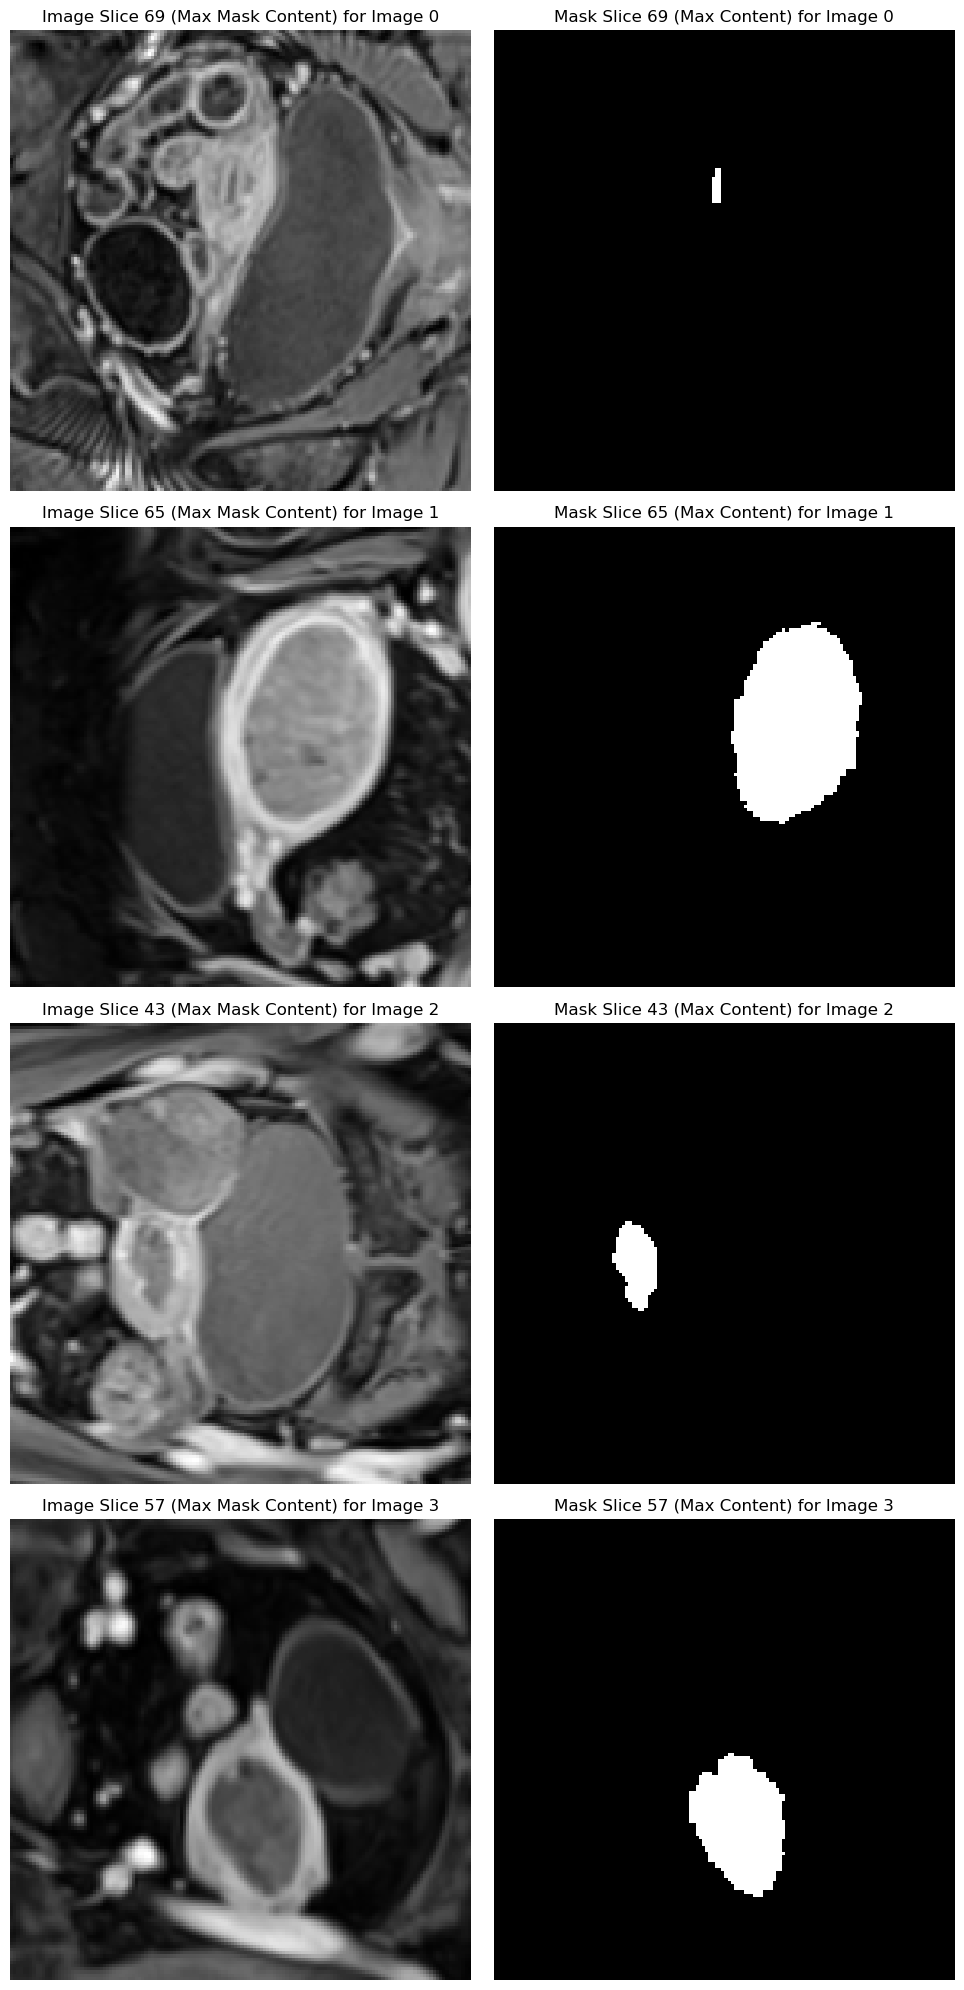

In [4]:
# Get a batch of data to visualize images and masks
show_max_mask_slices(next(iter(train_loader)))  # Visualize slices for all images in the batch

In [ ]:
learn.lr_find()

In [ ]:
16*11

In [5]:
# Clear GPU memory
torch.cuda.empty_cache()

# Set the desired GPU
torch.cuda.set_device(1)  # This ensures GPU 2 is used by default for all operations
device = torch.device("cuda:1")

# Instantiate the mean dice metric
dice_metric = MeanDice(include_background=False)

# Loss function
loss_func = DiceLoss(to_onehot_y=True, sigmoid=True)

# Define the model using the UNet function
modelname = 'UNet'
if modelname == 'UNet':
    dropout = 0.2
    model = monai_unet_model(dropout=dropout)
elif modelname == 'NNUnet':
    model = dyn_unet_model()

n_patience = 60
learn = Learner(
    dls,
    model,
    loss_func=loss_func,
    metrics=[dice_metric],
    cbs=[EarlyStoppingCallback(monitor='mean_dice', comp=operator.gt, patience=n_patience)]  # Adjust monitor name
)

# Train the model
n_epoch = 500
lr = 0.009
#learn.fit_one_cycle(n_epoch=n_epoch, lr_max=0.5e-2)
learn.fit_flat_cos(n_epoch=n_epoch, lr=lr, wd=1e-4)


epoch,train_loss,valid_loss,mean_dice,time
0,0.970011,0.965918,0.057569,03:50


single channel prediction, `to_onehot_y=True` ignored.


In [15]:
# Save the model
version = 'v0.1'
prepathmodels = os.path.join(prepath, 'ManuscriptDCE-MRI/models')

# Basename to use
basename = f'{modelname}-Monai-VIBE-{version}'

# Save the model weights
pathsave = os.path.join(prepathmodels, f'{basename}.pth')
print(f'Saving model weights to {pathsave}')
#torch.save(learn.model.state_dict(), pathsave)

Saving model weights to /home/erlend/GynKreftDropbox/EC/ManuscriptDCE-MRI/models/UNet-Monai-VIBE-v0.1.pth


In [17]:
# Collect all the key settings into a dictionary for saving to a CSV file
dropout = 0.2
settings = {
    "Batch Size": bs,
    "Image Size": img_size,
    "Image Paths": ", ".join(df.imgpath),
    "Train Samples": len(train_loader.dataset),
    "Validation Samples": len(val_loader.dataset),
    "Model Architecture": modelname,
    "Model Spatial Dimensions": 3,
    "Dropout": dropout,
    "Loss Function": "Dice Loss (to_onehot_y=True, sigmoid=True)",
    "Metric": "Mean Dice (include_background=False)",
    "Callback": "EarlyStoppingCallback(monitor='mean_dice', comp=gt, patience=60)",
    "Optimizer": "fit_flat_cos",
    "Epochs": n_epoch,
    "Learning Rate": lr,
}

# Convert the settings dictionary to a DataFrame
settings_df = pd.DataFrame([settings])

# Save the DataFrame to a CSV file
pathsave = os.path.join(prepathmodels, f'{basename}.csv')
print('Saving ' + pathsave)
settings_df.to_csv(pathsave, index=False)

# Display the DataFrame to the user for verification
settings_df

# Also save the dataframes
pathsave = os.path.join(prepathmodels, f'{basename}-dftrain.csv')
print('Saving ' + pathsave)
dftrain.to_csv(pathsave, index=False)

pathsave = os.path.join(prepathmodels, f'{basename}-dftest.csv')
print('Saving ' + pathsave)
dftest.to_csv(pathsave, index=False)


Saving /home/erlend/GynKreftDropbox/EC/ManuscriptDCE-MRI/models/UNet-Monai-VIBE-v0.1.csv
Saving /home/erlend/GynKreftDropbox/EC/ManuscriptDCE-MRI/models/UNet-Monai-VIBE-v0.1-dftrain.csv
Saving /home/erlend/GynKreftDropbox/EC/ManuscriptDCE-MRI/models/UNet-Monai-VIBE-v0.1-dftest.csv


In [ ]:
# Load the model
# Define the model architecture (same as used for training)
model = monai_unet_model(dropout=0.2)

# Load the saved weights
pathload = os.path.join(prepathmodels, f'UNet-Monai-20241119-{version}.pth')
print(f'Loading model weights from {pathload}')
model.load_state_dict(torch.load(pathload))
model.eval()  # Set the model to evaluation mode


In [ ]:
learn.recorder.plot_loss()

In [ ]:
import torch
import matplotlib.pyplot as plt

def compute_dice_score(preds, targets, threshold=0.5, apply_sigmoid=True):
    if apply_sigmoid:
        preds = torch.sigmoid(preds)
    
    preds = (preds > threshold).float()
    targets = targets.float()

    dice_scores = []
    for i in range(preds.shape[0]):
        intersection = (preds[i] * targets[i]).sum().float()
        union = preds[i].sum().float() + targets[i].sum().float()
        dice_score = 2. * intersection / (union + 1e-8)
        dice_scores.append(dice_score.item())

    return dice_scores
    
def show_max_mask_predictions(batch, predictions, dice_score):
    images, ground_truths = batch
    images = images.cpu().numpy()
    ground_truths = ground_truths.cpu().numpy()
    predictions = predictions.cpu().numpy()

    num_images = images.shape[0]
    fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 5))
    if num_images == 1:
        axes = [axes]

    i = 0
    for batch_idx in range(num_images):
        # Print shapes for debugging
        #print(f"Image shape: {images[batch_idx].shape}")
        #print(f"Ground Truth shape: {ground_truths[batch_idx].shape}")
        #print(f"Prediction shape: {predictions[batch_idx].shape}")
        
        # Ensure that the data has the expected 3D spatial dimensions
        if images[batch_idx].ndim < 3 or ground_truths[batch_idx].ndim < 3 or predictions[batch_idx].ndim < 3:
            print(f"Skipping index {batch_idx} due to incompatible dimensions.")
            continue

        image = images[batch_idx, 0] if images[batch_idx].ndim == 4 else images[batch_idx]  # Handle extra channel dimension
        ground_truth = ground_truths[batch_idx, 0] if ground_truths[batch_idx].ndim == 4 else ground_truths[batch_idx]
        pred = predictions[batch_idx, 0] if predictions[batch_idx].ndim == 4 else predictions[batch_idx]

        # Find the slice index with the maximum mask content in the ground truth
        slice_sums = ground_truth.sum(axis=(0, 1))
        max_slice_index = slice_sums.argmax()
        
        # Plot the image, ground truth mask, and predicted mask at the slice with max mask content
        axes[batch_idx][0].imshow(image[:, :, max_slice_index], cmap='gray')
        axes[batch_idx][0].set_title(f'Image Slice {max_slice_index} for Image {batch_idx}')
        axes[batch_idx][0].axis('off')

        axes[batch_idx][1].imshow(ground_truth[:, :, max_slice_index], cmap='gray')
        axes[batch_idx][1].set_title(f'Ground Truth Mask Slice {max_slice_index} for Image {batch_idx}')
        axes[batch_idx][1].axis('off')

        axes[batch_idx][2].imshow(pred[:, :, max_slice_index], cmap='gray')
        axes[batch_idx][2].set_title(f'Predicted Mask Slice {max_slice_index} for Image {batch_idx} (DSC={dice_score[i]:.2f})')
        axes[batch_idx][2].axis('off')

    
        # Example affine matrix: replace with your actual affine
        #affine = np.eye(4)  # This creates an identity affine matrix; replace if needed
        
        # Create a NIfTI image
        #nifti_img = nibabel.Nifti1Image(image, affine)

        # Save the NIfTI image to a file
        #output_path = 'image.nii.gz'  # Output path for the image
        #nibabel.save(nifti_img, output_path)
        #print(f"Image saved to {output_path}")

        # Create a NIfTI image
        #nifti_img = nibabel.Nifti1Image(ground_truth, affine)

        # Save the NIfTI image to a file
        #output_path = 'ground_truth.nii.gz'  # Output path for the image
        #nibabel.save(nifti_img, output_path)
        #print(f"Image saved to {output_path}")

        # Create a NIfTI image
        #nifti_img = nibabel.Nifti1Image(pred, affine)

        # Save the NIfTI image to a file
        #output_path = 'pred.nii.gz'  # Output path for the image
        #nibabel.save(nifti_img, output_path)
        #print(f"Image saved to {output_path}")

        #if i == 1:
        #    aa
        i = i + 1

        
    plt.tight_layout()
    plt.show()


# Validation and Visualization Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learn.model.to(device)
learn.model.eval()

with torch.no_grad():
    dice_scores = []
    for batch in val_loader:
        images, ground_truths = batch
        images, ground_truths = images.to(device), ground_truths.to(device)
        
        # Run predictions
        preds = learn.model(images).sigmoid()
        
        # Compute Dice score for the batch
        batch_dice = compute_dice_score(preds, ground_truths, apply_sigmoid=False)
        dice_scores.extend(batch_dice)
        
        # Visualize the predictions, images, and ground truths
        show_max_mask_predictions((images.cpu(), ground_truths.cpu()), preds.cpu(), batch_dice)

print(dice_scores)
# Compute the average Dice score over all batches
average_dice = sum(dice_scores) / len(dice_scores)
print(f"Average Dice Score on the validation set: {average_dice:.4f}")


In [ ]:
dice_scores